# Urban Safety — Classification: ML Models

Trains Logistic Regression, Decision Tree, Random Forest and XGBOOST classifiers to predict street-level safety class from built-environment features.

## Cell 1 — Imports and config

In [7]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set(rc={'figure.figsize': (8, 8)})
pd.set_option('display.float_format', '{:.3f}'.format)

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / 'csv' / 'segment_risk_scores_w-id.csv').exists() and (ROOT_DIR.parent / 'csv' / 'segment_risk_scores_w-id.csv').exists():
    ROOT_DIR = ROOT_DIR.parent

RISK_FEATURES_CSV = str(ROOT_DIR / 'csv' / 'segment_risk_scores_w-id.csv')
FEATURE_COLS = ['lighting_norm', 'visibility_norm', 'connectivity_norm', 'enclosure_norm', 'public_transport_proximity_m_norm', 'dominant_land_use_score_norm']

## Cell 2 — Load pre-labelled segment features

In [10]:
features = pd.read_csv(RISK_FEATURES_CSV)
print(f'✓ Loaded {len(features):,} segments from {RISK_FEATURES_CSV}')
print(f'  Columns: {list(features.columns)}')
print(f'\nRisk class distribution:')
print(features['risk_class'].value_counts().sort_index())

✓ Loaded 35,978 segments from c:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_scores_w-id.csv
  Columns: ['borough', 'lighting', 'lighting_norm', 'visibility', 'visibility_norm', 'connectivity', 'connectivity_norm', 'enclosure', 'enclosure_norm', 'public_transport_proximity_m', 'public_transport_proximity_m_norm', 'dominant_land_use_score', 'dominant_land_use_score_norm', 'risk_score', 'risk_class', 'location_id']

Risk class distribution:
risk_class
high        697
low       21176
medium    14105
Name: count, dtype: int64


## Cell 3 — Model training
Trains Logistic Regression, Decision Tree, and Random Forest on the combined multi-borough dataset.

In [ ]:
# Derive target from numeric `risk_score` only (ignore any existing `risk_class`)
risk_numeric = pd.to_numeric(features['risk_score'], errors='coerce')
features['risk_class_derived'] = pd.cut(
    risk_numeric,
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=['low', 'medium', 'high'],
    include_lowest=True
).astype(str)

data = features[FEATURE_COLS + ['risk_class_derived']].dropna(subset=['risk_class_derived']).copy()
X = data[FEATURE_COLS]
y = data['risk_class_derived']

print(f'Training data shape: X = {X.shape}, y = {y.shape}')
print(f'Class distribution:\n{y.value_counts()}\n')

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
 )
print(f'Train set: {X_train.shape[0]:,} samples')
print(f'Test set:  {X_test.shape[0]:,} samples\n')

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f'Logistic Regression accuracy: {(lr_pred == y_test).mean():.3f}\n')
print(classification_report(y_test, lr_pred))

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print(f'Decision Tree accuracy: {(dt_pred == y_test).mean():.3f}\n')
print(classification_report(y_test, dt_pred))

rf = RandomForestClassifier(n_estimators=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f'Random Forest (5 trees) accuracy: {(rf_pred == y_test).mean():.3f}\n')
print(classification_report(y_test, rf_pred))

Training data shape: X = (35978, 6), y = (35978,)
Class distribution:
risk_class
low       21176
medium    14105
high        697
Name: count, dtype: int64

Train set: 28,782 samples
Test set:  7,196 samples

Logistic Regression accuracy: 0.999

              precision    recall  f1-score   support

        high       1.00      0.96      0.98       139
         low       1.00      1.00      1.00      4236
      medium       1.00      1.00      1.00      2821

    accuracy                           1.00      7196
   macro avg       1.00      0.99      0.99      7196
weighted avg       1.00      1.00      1.00      7196

Decision Tree accuracy: 0.970

              precision    recall  f1-score   support

        high       0.87      0.88      0.87       139
         low       0.98      0.98      0.98      4236
      medium       0.96      0.96      0.96      2821

    accuracy                           0.97      7196
   macro avg       0.94      0.94      0.94      7196
weighted avg     

## Cell 4 — Confusion matrices

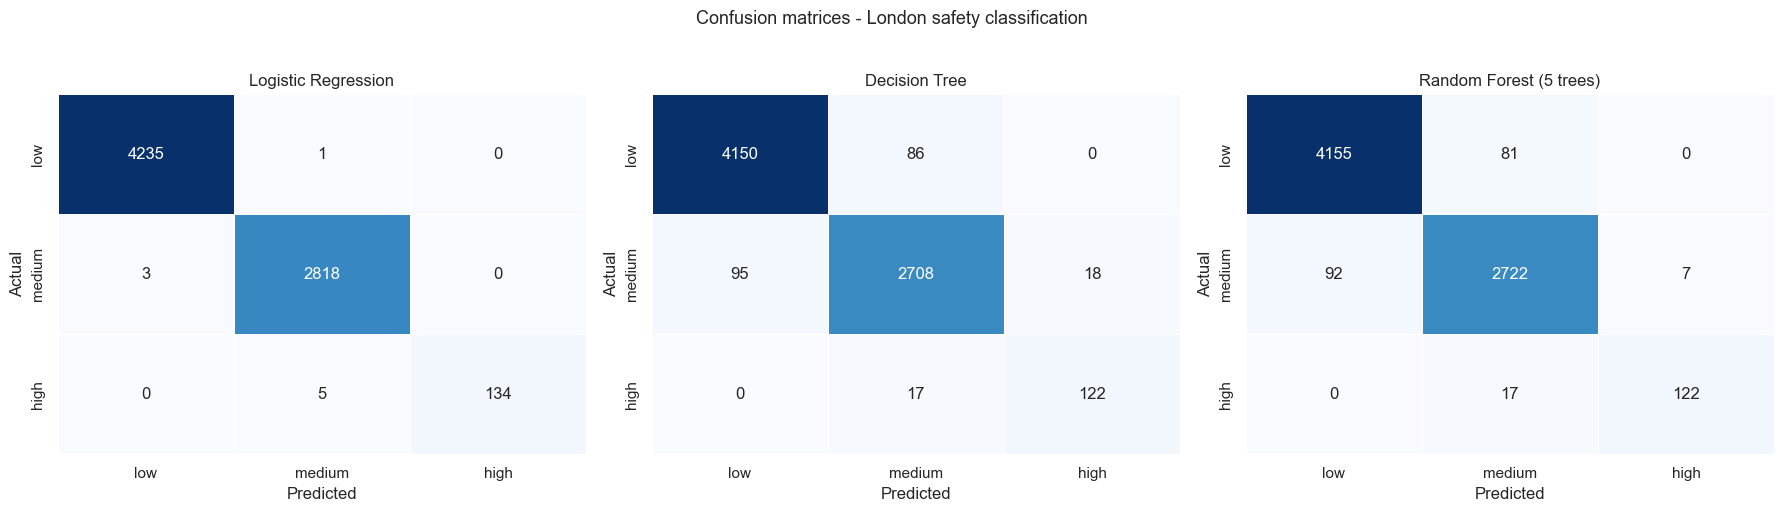

In [13]:
classes = ['low', 'medium', 'high']
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pred, title in zip(
    axes, [lr_pred, dt_pred, rf_pred],
    ['Logistic Regression', 'Decision Tree', 'Random Forest (5 trees)']
):
    cm = confusion_matrix(y_test, pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion matrices - London safety classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Feature importance

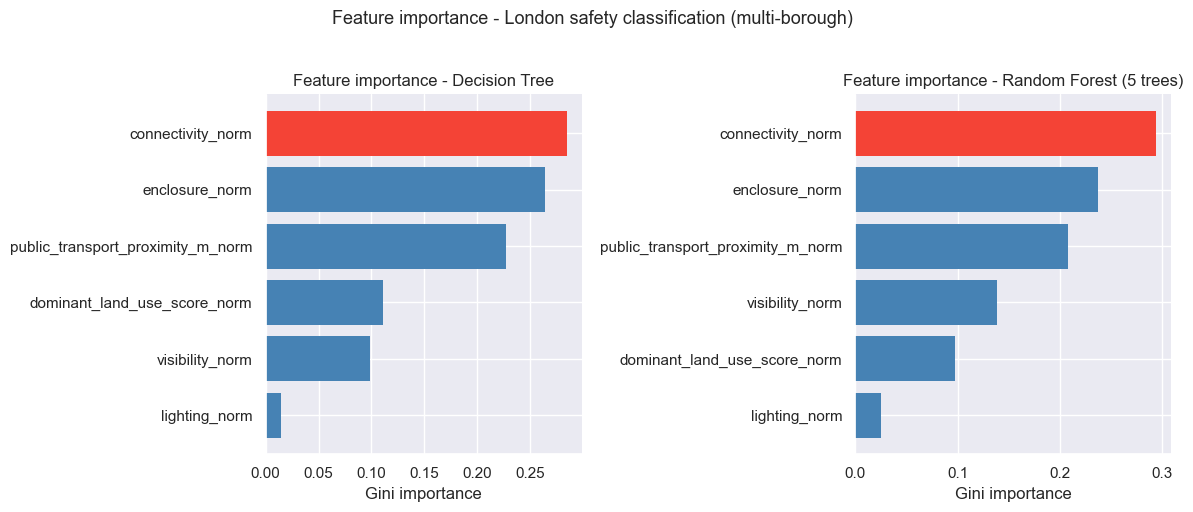

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in zip(axes, [dt, rf], ['Decision Tree', 'Random Forest (5 trees)']):
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    colors = ['#F44336' if v == importances.max() else 'steelblue' for v in importances.values]
    ax.barh(importances.index, importances.values, color=colors, edgecolor='none')
    ax.set_title(f'Feature importance - {title}', fontsize=12)
    ax.set_xlabel('Gini importance')
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Feature importance - London safety classification (multi-borough)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

The models were trained on **35,978 street segments** from the combined London dataset using six normalized built-environment features.
The target is **risk_class** with three classes: `low`, `medium`, and `high`.

**Accuracy summary:**

| Model | Accuracy |
|---|---|
| Logistic Regression | 99.9% |
| Decision Tree | 97.0% |
| Random Forest (5 trees) | 97.3% |

The strong performance of the tree-based models suggests the class boundaries are largely non-linear in this feature space.
Logistic Regression also performs extremely well, which indicates the current feature set separates the classes very cleanly.

The plots and training cells now use the same `risk_class` labels as the input CSV, so the notebook is internally consistent from loading through evaluation.

**Next interpretation step:** use the feature-importance plots to identify which normalized features contribute most to the tree-based models, then compare that with the PCA findings in `03_PCA.ipynb`.